## Build a basic chatbot with langgraph(GRAPH API)

- Components of langgraph: 
1. Edges
2. Nodes
3. State

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages # reducers



In [2]:
class State(TypedDict):
    # Messages have the type "list". The 'add_messages' function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather thatn overwriting them)
    messages:Annotated[list,add_messages]




In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="openai/gpt-oss-20b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.2'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7a3e4fefec00>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7a3e4fabed20>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [5]:
# Node functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [6]:
graph_builder = StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)

## Adding edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)
# compile the graph

graph = graph_builder.compile()

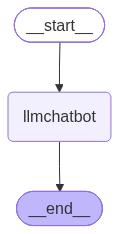

In [7]:
## visulaize the graph
from IPython.display import Image,display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as err:
    print(err)   

In [9]:
response = graph.invoke({"messages":"Hi"})

In [14]:
response["messages"][-1].content

'Hello! How can I help you today?'

In [8]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I’m doing great—thanks for asking. How can I help you today?


# Chatbot with tool

In [9]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian Cr

In [10]:
# custom function
def multiply(a:int,b:int) -> int:
    """
    Multiply a and b

    Args:
        a (int) : first int
        b (int) : second int

    Returns:
        int: _description_output int    
    """
    return a*b
    

In [15]:
tools=[tool,multiply]
llm_with_tool = llm.bind_tools(tools)
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.2'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x78a15080a090>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x78a15072acf0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted 

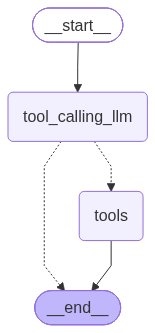

In [29]:
## StateGraph
from langgraph.graph  import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

# Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# adding edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call --> tools_condition_routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition # this actually managing the condition
)
builder.add_edge("tools",END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
response = graph.invoke({"messages":"What is the recent ai news"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_d2dc2f0f-2ecc-4e33-8364-40267c8ad727)
 Call ID: fc_d2dc2f0f-2ecc-4e33-8364-40267c8ad727
  Args:
    query: recent AI news September 2026
    search_depth: advanced
    time_range: month
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news September 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.globalxetfs.com/articles/the-next-big-theme-september-2026", "title": "The Next Big Theme: September 2026 - Global X ETFs", "content": "Anthropic introduced the Model Hardware Standard (MHS), a shared framework that allows AI agents to control programmable equipment safely, including microscopes, liquid handlers, lasers, and robotic arms

In [31]:
response = graph.invoke({"messages":"What is 5 multiplied by 2 and then multiply 10"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2 and then multiply 10
================================== Ai Message ==================================

\(5 \times 2 = 10\).  
Then \(10 \times 10 = 100\).  

So the result is **100**.


In [32]:
response = graph.invoke({"messages":"Give me the recent ai news and then multiply by 5 by 10"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply by 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_ba616033-c760-4d30-9447-3d4e25062c73)
 Call ID: fc_ba616033-c760-4d30-9447-3d4e25062c73
  Args:
    query: recent AI news
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/google-ai-updates-august-2026", "title": "The latest AI news we announced in August 2026", "content": "In August, we continued advancing AI responsibly — making it faster, more accessible, and truly practical for everyone, from software developers and students to creatives and scientists. We’re bringing intelligence directl

# ReAct Architeture

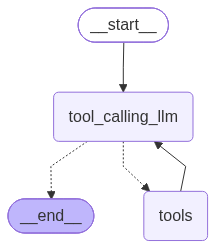

In [33]:
## StateGraph
from langgraph.graph  import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

# Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# adding edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call --> tools_condition_routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition # this actually managing the condition
)
builder.add_edge("tools","tool_calling_llm")
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
response = graph.invoke({"messages":"Give me the recent ai news and then multiply by 5 by 10"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply by 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_a71fdaa5-e5d6-448b-b5bb-a5170344677d)
 Call ID: fc_a71fdaa5-e5d6-448b-b5bb-a5170344677d
  Args:
    query: recent AI news
    search_depth: basic
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.wsj.com/tech/ai", "title": "Artificial Intelligence - Latest AI News and Analysis - WSJ.com", "content": "View All\n\nSenator Elizabeth Warren, a Democrat from Massachusetts, during a Senate Banking, Housing, and Urban Affairs Committee hearing in Washington, DC, US, on Thursday, May 18, 2023. Two senators on the committee say they have found flaws in regula

# Adding memory In Agentic Graph

In [35]:
response = graph.invoke({"messages":"Hello my name is kumar"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello my name is kumar
================================== Ai Message ==================================

Hello Kumar! 👋 How can I help you today?


In [36]:
response = graph.invoke({"messages":"what is my name?"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is my name?
================================== Ai Message ==================================

I’m not sure what your name is. Could you let me know?


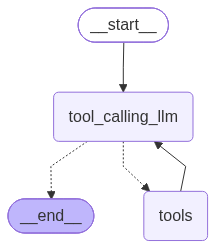

In [37]:
## StateGraph
from langgraph.graph  import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

# Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# adding edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call --> tools_condition_routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition # this actually managing the condition
)
builder.add_edge("tools","tool_calling_llm")
graph = builder.compile(checkpointer=memory) # in memory

display(Image(graph.get_graph().draw_mermaid_png()))

In [38]:
config = {"configurable":{"thread_id":"1"}}
response = graph.invoke({"messages":"Hi my name is Kumar"},config=config)
response

{'messages': [HumanMessage(content='Hi my name is Kumar', additional_kwargs={}, response_metadata={}, id='9ff3585b-f4d2-461d-91b9-79001dbb6753'),
  AIMessage(content='Hello, Kumar! How can I help you today?', additional_kwargs={'reasoning_content': 'User: "Hi my name is Kumar". Probably they want a greeting or ask something. We can respond friendly. No tool needed.'}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 347, 'total_tokens': 395, 'completion_time': 0.04937334, 'completion_tokens_details': {'reasoning_tokens': 28}, 'prompt_time': 0.018329437, 'prompt_tokens_details': None, 'queue_time': 0.395880482, 'total_time': 0.067702777}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_d23c14756c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0b961-07f4-7231-9ba8-5767bc534101-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 347, 'output_tokens': 48, 'to

In [39]:
response['messages'][-1].content

'Hello, Kumar! How can I help you today?'

In [40]:
response = graph.invoke({"messages":"Hey what is my name?"},config=config)
response['messages'][-1].content

'Your name is Kumar.'

In [41]:
response = graph.invoke({"messages":"Hey do you remember my name?"},config=config)
response['messages'][-1].content

'Yes, your name is Kumar.'

In [17]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [18]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

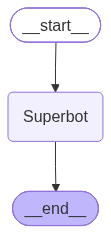

In [19]:
graph = StateGraph(State)

#node
graph.add_node("Superbot",superbot)

#edges
graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)

graph_builder = graph.compile(checkpointer=memory)

#display
from IPython.display import Image,display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [22]:
## Invocation

config = {"configurable":{"thread_id":"2"}}
graph_builder.invoke({"messages":"Hi, My name is kumar And I like cricket."},config)

{'messages': [HumanMessage(content='Hi, My name is kumar And I like cricket.', additional_kwargs={}, response_metadata={}, id='69e03222-9610-4abb-9224-735adebeb0f1'),
  AIMessage(content="Hey Kumar! 👋 Great to meet a fellow cricket fan. Which teams or players do you follow the most? Or is there a particular format—Test, ODI, T20—you're most into? Let's chat about it!", additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi, My name is kumar And I like cricket." They likely want a friendly response. We can ask about cricket, maybe ask what aspects they like. Also we should confirm we are not providing disallowed content. It\'s safe. Just respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 116, 'prompt_tokens': 83, 'total_tokens': 199, 'completion_time': 0.11975265, 'completion_tokens_details': {'reasoning_tokens': 61}, 'prompt_time': 0.003977474, 'prompt_tokens_details': None, 'queue_time': 0.345519935, 'total_time': 0.123730124}, 'model_

# Streaming

- Methods: stream() and astream()
    1. These methods are sync and async methods for streaming back results
- Additional parameters in streaming modes for graph state
1. value: this streams the full state of the graph after each node is called.
2. update: This streams updates to the state of the graph after each node is called 

In [23]:
# Create a thread
config = {"configurable": {"thread_id":"3"}}

for chunk in graph_builder.stream({"messages":"Hi, My name is krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content='Hi Krish! 👋 Great to meet you. Cricket’s a fantastic sport—do you have a favorite team or player? Or maybe you’re more into the matches themselves? Let me know what you’re most excited about, and we can dive into the game!', additional_kwargs={'reasoning_content': 'User says "Hi, My name is krish And I like cricket". We need to respond as a friendly conversation. We should ask about cricket preferences, maybe ask about favorite teams, players. Also mention that we can talk about cricket. We should keep it concise.'}, response_metadata={'token_usage': {'completion_tokens': 118, 'prompt_tokens': 82, 'total_tokens': 200, 'completion_time': 0.146028074, 'completion_tokens_details': {'reasoning_tokens': 55}, 'prompt_time': 0.006095729, 'prompt_tokens_details': None, 'queue_time': 0.31748479, 'total_time': 0.152123803}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_9340e7d14d', 'service_tier': 'on_demand', 'finish_reason': 'stop',

In [24]:
for chunk in graph_builder.stream({"messages":"Hi, My name is krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is krish And I like cricket', additional_kwargs={}, response_metadata={}, id='2be7559c-6c2d-4d7a-bcab-392f8264bef0'), AIMessage(content='Hi Krish! 👋 Great to meet you. Cricket’s a fantastic sport—do you have a favorite team or player? Or maybe you’re more into the matches themselves? Let me know what you’re most excited about, and we can dive into the game!', additional_kwargs={'reasoning_content': 'User says "Hi, My name is krish And I like cricket". We need to respond as a friendly conversation. We should ask about cricket preferences, maybe ask about favorite teams, players. Also mention that we can talk about cricket. We should keep it concise.'}, response_metadata={'token_usage': {'completion_tokens': 118, 'prompt_tokens': 82, 'total_tokens': 200, 'completion_time': 0.146028074, 'completion_tokens_details': {'reasoning_tokens': 55}, 'prompt_time': 0.006095729, 'prompt_tokens_details': None, 'queue_time': 0.31748479, 'total_time': 0.1

In [25]:
# Create a thread
config = {"configurable": {"thread_id":"4"}}

for chunk in graph_builder.stream({"messages":"Hi, My name is krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content='Hello Krish! 👋 It’s great to meet a cricket fan. Which team or player do you follow most? Or maybe you have a favorite match you’d like to chat about?', additional_kwargs={'reasoning_content': 'User says "Hi, My name is krish And I like cricket". They are just greeting. We can respond warmly, maybe ask about cricket.'}, response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 82, 'total_tokens': 160, 'completion_time': 0.078999137, 'completion_tokens_details': {'reasoning_tokens': 31}, 'prompt_time': 0.00394373, 'prompt_tokens_details': None, 'queue_time': 0.309478188, 'total_time': 0.082942867}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_4f7e7dc26e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0b975-4742-7cd3-aefd-db5e86311c40-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 82, 'output_tokens': 78, 'total_t

In [26]:
for chunk in graph_builder.stream({"messages":"I also like football"},config,stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content='That’s awesome—cricket and football make for a great sports combo! 🎉\n\n- **Cricket:** Are you into the T20 leagues (like the IPL or Big Bash) or the longer formats (Test, ODIs)?\n- **Football:** Do you follow a particular league (Premier League, La Liga, Serie A, etc.) or a national team?\n\nLet me know, and we can dive into your favorites, recent matches, or even compare the two sports if you’re curious!', additional_kwargs={'reasoning_content': 'The user says they also like football. We can respond. The user has not asked a question, so we can continue conversation. We should ask about preferences. We should be friendly.'}, response_metadata={'token_usage': {'completion_tokens': 148, 'prompt_tokens': 134, 'total_tokens': 282, 'completion_time': 0.150207865, 'completion_tokens_details': {'reasoning_tokens': 38}, 'prompt_time': 0.006449795, 'prompt_tokens_details': None, 'queue_time': 0.341528953, 'total_time': 0.15665766}, 'model_name': '